In [37]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("Video_Games_Sales_preprocessing.csv")
df = df.drop(columns=["User_Score", "User_Score_Clean"])
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count,Developer,Rating,User_Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,322.0,Nintendo,E,80.0
1,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,709.0,Nintendo,E,83.0
2,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,192.0,Nintendo,E,80.0
3,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,431.0,Nintendo,E,85.0
4,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,129.0,Nintendo,E,66.0


In [39]:
print("Shape:", df.shape)

# Target column: user rating (assumed 0–100)
target_col = "User_Rating"
print("Target min/max:", df[target_col].min(), df[target_col].max())

Shape: (7590, 16)
Target min/max: 0.0 97.0


In [40]:
# Target column
target_col = "User_Rating"

# Catergorices Features 
cat_cols = ["Platform", "Genre", "Rating"]

# Numeric Features
num_cols = [
    "Year_of_Release",
    "Critic_Score",
    "Critic_Count",
    "User_Count",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

needed_cols = [target_col] + cat_cols + num_cols
df = df.dropna(subset=needed_cols).reset_index(drop=True)
print("After dropping NAs, shape:", df.shape)


After dropping NAs, shape: (6826, 16)


In [41]:
# WIDE: Platform × Genre cross features
df["Platform_x_Genre"] = df["Platform"] + "__" + df["Genre"]
X_wide_df = pd.get_dummies(df[["Platform_x_Genre"]], drop_first=False)

print("X_wide_df shape:", X_wide_df.shape)


X_wide_df shape: (6826, 197)


In [42]:
# DEEP: numeric (standardized) + one-hot categoricals

# One-hot encode categorical features
X_cat_df = pd.get_dummies(df[cat_cols], drop_first=True)

# Standardize numeric features
X_num_df = df[num_cols].copy()
X_num_df = (X_num_df - X_num_df.mean()) / X_num_df.std()

# Combine numeric + categorical to form deep input
X_deep = np.hstack([X_num_df.values, X_cat_df.values]).astype(np.float32)

# Wide input as numpy
X_wide = X_wide_df.values.astype(np.float32)

# Target vector
y = df[target_col].values.reshape(-1, 1).astype(np.float32)

print("X_wide shape:", X_wide.shape)
print("X_deep shape:", X_deep.shape)
print("y shape:", y.shape)


X_wide shape: (6826, 197)
X_deep shape: (6826, 42)
y shape: (6826, 1)


In [43]:
print("Any NaN in X_wide?", np.isnan(X_wide).any())
print("Any NaN in X_deep?", np.isnan(X_deep).any())
print("Any NaN in y?", np.isnan(y).any())

print("Any inf in X_wide?", np.isinf(X_wide).any())
print("Any inf in X_deep?", np.isinf(X_deep).any())
print("Any inf in y?", np.isinf(y).any())


Any NaN in X_wide? False
Any NaN in X_deep? False
Any NaN in y? False
Any inf in X_wide? False
Any inf in X_deep? False
Any inf in y? False


In [44]:
def train_val_split(Xw, Xd, y, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    n = Xw.shape[0]
    idx = np.arange(n)
    rng.shuffle(idx)

    n_val = int(n * val_ratio)
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    Xw_train, Xw_val = Xw[train_idx], Xw[val_idx]
    Xd_train, Xd_val = Xd[train_idx], Xd[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    return Xw_train, Xw_val, Xd_train, Xd_val, y_train, y_val

Xw_train, Xw_val, Xd_train, Xd_val, y_train, y_val = train_val_split(X_wide, X_deep, y)

print("Train size:", Xw_train.shape[0])
print("Val size:", Xw_val.shape[0])


Train size: 5461
Val size: 1365


In [45]:
rng = np.random.default_rng(0)

D_wide = Xw_train.shape[1]
W_wide = rng.normal(0, 0.01, size=(D_wide, 1)).astype(np.float32)
b_wide = np.zeros((1, 1), dtype=np.float32)

D_deep_in = Xd_train.shape[1]
H1 = 32   # hidden layer 1 size
H2 = 16   # hidden layer 2 size
D_out = 1 # regression output

W1 = rng.normal(0, 0.01, size=(D_deep_in, H1)).astype(np.float32)
b1 = np.zeros((1, H1), dtype=np.float32)

W2 = rng.normal(0, 0.01, size=(H1, H2)).astype(np.float32)
b2 = np.zeros((1, H2), dtype=np.float32)

W3 = rng.normal(0, 0.01, size=(H2, D_out)).astype(np.float32)
b3 = np.zeros((1, D_out), dtype=np.float32)


In [46]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)

def forward_batch(Xw_batch, Xd_batch):

    # Deep part
    z1 = Xd_batch @ W1 + b1      # (B, H1)
    a1 = relu(z1)
    z2 = a1 @ W2 + b2            # (B, H2)
    a2 = relu(z2)
    y_deep = a2 @ W3 + b3        # (B, 1)

    # Wide part
    y_wide = Xw_batch @ W_wide + b_wide  # (B, 1)

    # Combined prediction
    y_pred = y_deep + y_wide

    cache = (Xd_batch, Xw_batch, z1, a1, z2, a2, y_deep, y_wide, y_pred)
    return y_pred, cache

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


In [47]:
def train(num_epochs=100, batch_size=128, lr=0.001):
    global W1, b1, W2, b2, W3, b3, W_wide, b_wide

    n_train = Xw_train.shape[0]
    num_batches = int(np.ceil(n_train / batch_size))

    for epoch in range(1, num_epochs + 1):
        perm = np.random.permutation(n_train)
        Xw_shuf = Xw_train[perm]
        Xd_shuf = Xd_train[perm]
        y_shuf = y_train[perm]

        epoch_loss_sum = 0.0

        for b in range(num_batches):
            start = b * batch_size
            end = min((b + 1) * batch_size, n_train)

            Xw_batch = Xw_shuf[start:end]
            Xd_batch = Xd_shuf[start:end]
            y_batch = y_shuf[start:end]

            B = Xw_batch.shape[0]  # actual batch size

            # Forward 
            y_pred, cache = forward_batch(Xw_batch, Xd_batch)
            loss = mse_loss(y_pred, y_batch)
            epoch_loss_sum += loss * B

            # Backward 
            (Xd_b, Xw_b, z1, a1, z2, a2, y_deep, y_wide, y_hat) = cache

            # dL/dy_hat (MSE)
            dL_dy = 2.0 * (y_hat - y_batch) / B    # (B, 1)

            # --- Wide part grads ---
            dL_dW_wide = Xw_b.T @ dL_dy           # (D_wide, 1)
            dL_db_wide = np.sum(dL_dy, axis=0, keepdims=True)  # (1, 1)

            # Deep part grads 
            # y_deep = a2 @ W3 + b3
            dL_dW3 = a2.T @ dL_dy                 # (H2, 1)
            dL_db3 = np.sum(dL_dy, axis=0, keepdims=True)      # (1, 1)

            dL_da2 = dL_dy @ W3.T                 # (B, H2)
            dL_dz2 = dL_da2 * relu_grad(z2)       # (B, H2)

            dL_dW2 = a1.T @ dL_dz2                # (H1, H2)
            dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)     # (1, H2)

            dL_da1 = dL_dz2 @ W2.T                # (B, H1)
            dL_dz1 = dL_da1 * relu_grad(z1)       # (B, H1)

            dL_dW1 = Xd_b.T @ dL_dz1              # (D_deep_in, H1)
            dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)     # (1, H1)

            # Update parameters 
            W_wide -= lr * dL_dW_wide
            b_wide -= lr * dL_db_wide

            W3 -= lr * dL_dW3
            b3 -= lr * dL_db3

            W2 -= lr * dL_dW2
            b2 -= lr * dL_db2

            W1 -= lr * dL_dW1
            b1 -= lr * dL_db1

        # Average train loss over all samples
        epoch_loss = epoch_loss_sum / n_train

        # Validation loss
        y_val_pred, _ = forward_batch(Xw_val, Xd_val)
        val_loss = mse_loss(y_val_pred, y_val)

        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Train MSE: {epoch_loss:.4f} | Val MSE: {val_loss:.4f}")


In [48]:
# Train
train(num_epochs=120, batch_size=128, lr=0.0001)

# Final validation RMSE
y_val_pred, _ = forward_batch(Xw_val, Xd_val)
val_mse = mse_loss(y_val_pred, y_val)
val_rmse = sqrt(val_mse)
print("Validation RMSE:", val_rmse)

# Baseline: always predict mean of y_train
y_mean = y_train.mean()
baseline_mse = np.mean((y_val - y_mean) ** 2)
baseline_rmse = float(np.sqrt(baseline_mse))

print("Baseline (mean) RMSE:", baseline_rmse)


Epoch   1 | Train MSE: 5280.2653 | Val MSE: 5209.7041
Epoch   5 | Train MSE: 4622.4836 | Val MSE: 4560.2471
Epoch  10 | Train MSE: 3528.9207 | Val MSE: 3234.3062
Epoch  15 | Train MSE: 120.6762 | Val MSE: 121.4411
Epoch  20 | Train MSE: 115.8631 | Val MSE: 116.2336
Epoch  25 | Train MSE: 114.3998 | Val MSE: 114.6496
Epoch  30 | Train MSE: 113.6895 | Val MSE: 114.0818
Epoch  35 | Train MSE: 113.3656 | Val MSE: 113.6447
Epoch  40 | Train MSE: 113.1611 | Val MSE: 113.2281
Epoch  45 | Train MSE: 112.9622 | Val MSE: 113.0929
Epoch  50 | Train MSE: 112.8185 | Val MSE: 113.0384
Epoch  55 | Train MSE: 112.7204 | Val MSE: 112.9823
Epoch  60 | Train MSE: 112.7074 | Val MSE: 112.7044
Epoch  65 | Train MSE: 112.5443 | Val MSE: 112.6114
Epoch  70 | Train MSE: 112.4646 | Val MSE: 112.8099
Epoch  75 | Train MSE: 112.4243 | Val MSE: 112.6786
Epoch  80 | Train MSE: 112.3518 | Val MSE: 112.7151
Epoch  85 | Train MSE: 112.1927 | Val MSE: 112.2337
Epoch  90 | Train MSE: 112.3242 | Val MSE: 112.4252
Epoch 

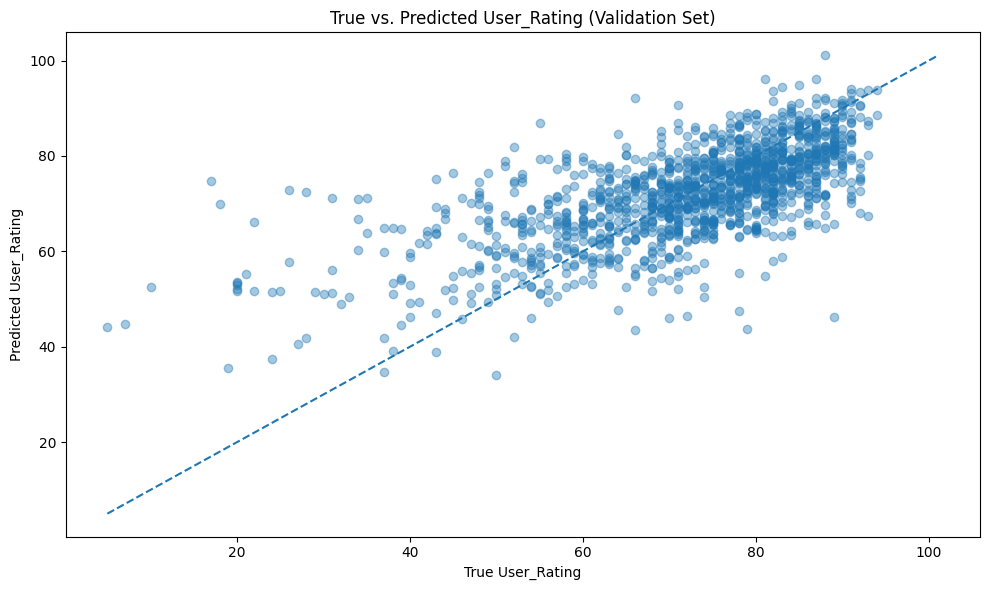

In [ ]:
import matplotlib.pyplot as plt

y_true_val = y_val.reshape(-1)
y_pred_val = y_val_pred.reshape(-1)

plt.figure(figsize=(10, 6))
plt.scatter(y_true_val, y_pred_val, alpha=0.4)

# 45-degree reference line
min_val = min(y_true_val.min(), y_pred_val.min())
max_val = max(y_true_val.max(), y_pred_val.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True User_Rating")
plt.ylabel("Predicted User_Rating")
plt.title("True vs. Predicted User_Rating (Validation Set)")
plt.tight_layout()
plt.show()


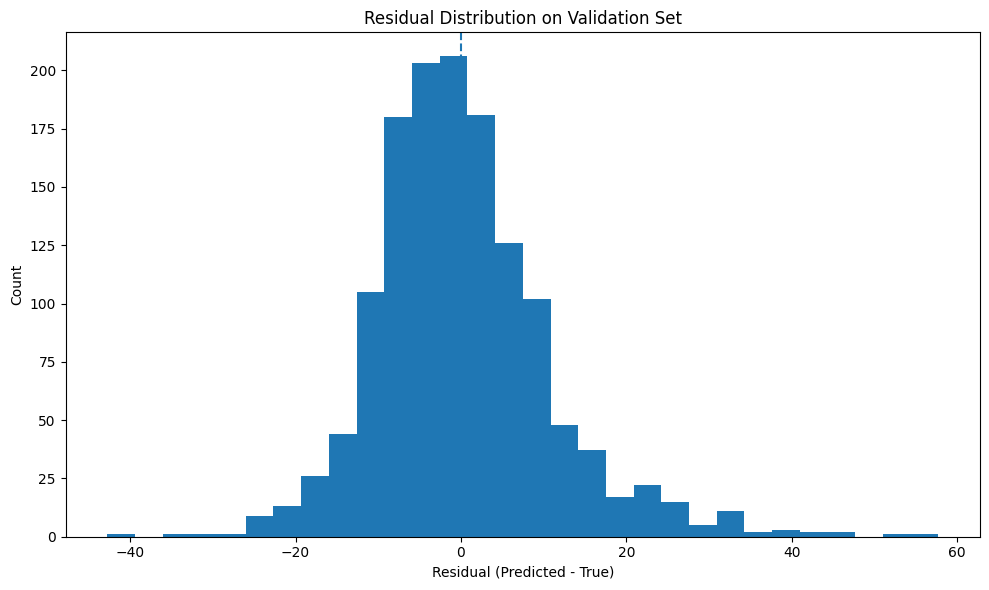

In [52]:
# Residuals on validation set
residuals_val = y_pred_val - y_true_val

plt.figure(figsize=(10, 6))
plt.hist(residuals_val, bins=30)
plt.axvline(0, linestyle="--")

plt.xlabel("Residual (Predicted - True)")
plt.ylabel("Count")
plt.title("Residual Distribution on Validation Set")
plt.tight_layout()
plt.show()
